# Week 2 Lab
## Exercise 1

### Q1: myFnLinReg

In [1]:
import numpy as np

def myFnLinReg(x, y):
    x, y = np.array(x, float), np.array(y, float)
    xm, ym = x.mean(), y.mean()
    slope = np.sum((x-xm)*(y-ym)) / np.sum((x-xm)**2)
    intercept = ym - slope*xm
    return intercept, slope

In [2]:
x = [1,2,3,4,5]
y = [2,4,5,4,5]
b0, b1 = myFnLinReg(x, y)
print("Intercept:", b0)
print("Slope:", b1)

Intercept: 2.2
Slope: 0.6


### Q2: Fit on mtcars (mpg ~ wt)

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("mtcars.csv")
x, y = df["wt"].values, df["mpg"].values

xtr, xte, ytr, yte = train_test_split(x, y, test_size=0.2, random_state=42)
b0, b1 = myFnLinReg(xtr, ytr)

print("Intercept =", b0)
print("Slope =", b1)
print(f"mpg = {b0:.4f} + ({b1:.4f})*wt")

Intercept = 36.93731031351841
Slope = -5.336941400557081
mpg = 36.9373 + (-5.3369)*wt


### Q3: Predict mpg at wt = 5.5

In [4]:
wt_q = 5.5
pred = b0 + b1*wt_q
print("Predicted MPG:", pred)

Predicted MPG: 7.584132610454464


### Q4: RMSE and R2 on test set

In [5]:
yp = b0 + b1*xte
rmse = np.sqrt(np.mean((yte-yp)**2))
r2 = 1 - np.sum((yte-yp)**2)/np.sum((yte-yte.mean())**2)
print("RMSE =", rmse)
print("R2 =", r2)

RMSE = 3.5321361326991405
R2 = 0.6879761857596272


### Q5: SGD (feature scaled for stable convergence)

In [6]:
import matplotlib.pyplot as plt

xm, xs = xtr.mean(), xtr.std()
xs_tr = (xtr-xm)/xs

m, b = 0.0, 0.0
lr, epochs = 0.01, 200
n = len(xs_tr)
cost_sgd = []

for _ in range(epochs):
    for i in range(n):
        yp = m*xs_tr[i] + b
        dm = -2*xs_tr[i]*(ytr[i]-yp)
        db = -2*(ytr[i]-yp)
        m -= lr*dm
        b -= lr*db
    cost_sgd.append(np.mean((ytr - (m*xs_tr+b))**2))

slope_sgd, int_sgd = m/xs, b - m*xm/xs
print("SGD slope, intercept =", slope_sgd, int_sgd)

SGD slope, intercept = -5.518787040959595 37.5168266451889


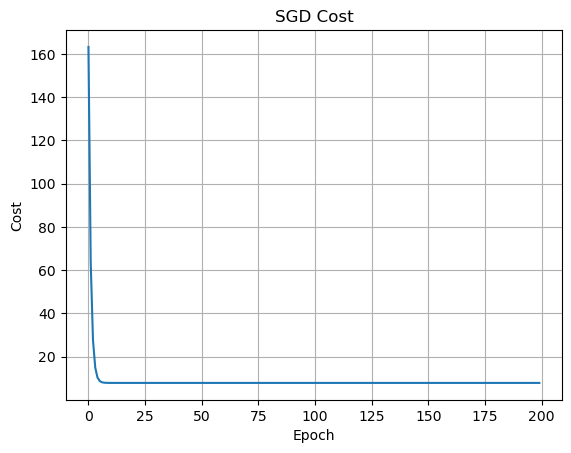

In [7]:
plt.plot(cost_sgd)
plt.xlabel("Epoch"); plt.ylabel("Cost")
plt.title("SGD Cost")
plt.grid(True)
plt.show()

### Q5 (cont.): Mini-batch GD

In [8]:
m, b = 0.0, 0.0
bs = 5
cost_mb = []

for _ in range(epochs):
    for i in range(0, n, bs):
        xb, yb = xs_tr[i:i+bs], ytr[i:i+bs]
        yp = m*xb + b
        dm = (-2/len(xb))*np.sum(xb*(yb-yp))
        db = (-2/len(xb))*np.sum(yb-yp)
        m -= lr*dm
        b -= lr*db
    cost_mb.append(np.mean((ytr - (m*xs_tr+b))**2))

slope_mb, int_mb = m/xs, b - m*xm/xs
print("Mini-batch slope, intercept =", slope_mb, int_mb)

Mini-batch slope, intercept = -5.369641366525802 37.03701436217166


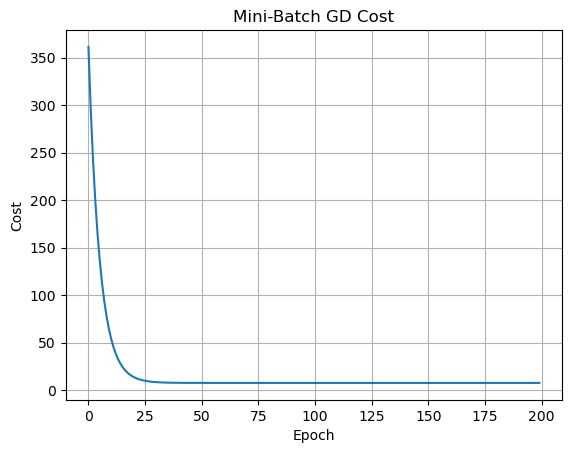

In [9]:
plt.plot(cost_mb)
plt.xlabel("Epoch"); plt.ylabel("Cost")
plt.title("Mini-Batch GD Cost")
plt.grid(True)
plt.show()

## Exercise 2

### Q1-Q3: Best 5 features, model on best 3, accuracy

In [16]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("boston.csv")

corr = df.select_dtypes(include=[float,int]).corr()["MEDV"].abs()
top5 = corr.drop("MEDV").nlargest(5).index.tolist()
print("Best 5:", top5)

top3 = top5[:3]
X, y = df[top3], df["MEDV"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(Xtr, ytr)
print("Coefs:", dict(zip(top3, model.coef_)), "Intercept:", model.intercept_)

yp = model.predict(Xte)
print("R2 =", r2_score(yte, yp))
print("MSE =", mean_squared_error(yte, yp))

Best 5: ['RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX']
Coefs: {'RM': 7.427176655524828, 'PTRATIO': -0.9917304749493003, 'INDUS': -0.21944153484125511} Intercept: -3.5300970071692426
R2 = 0.5281750671890879
MSE = 34.79438092602947
